In [1]:
FFMPEG_PATH = r"C:/ffmpeg/bin/ffmpeg.exe"
VIDEO_PATH = r".\data\2025-11-20_15-30-11-a3a383b4\95cbe6dd_0.0-323.503.mp4"
OUTPUT_DIR = r".\videos\velo_1"

FPS = 24
SCALE = 0.5
SIZE = (int(1600 * SCALE), int(1200 * SCALE))
START_FRAME = 100     # frame de départ (94 = début)
END_FRAME = 200      # frame de fin (7730 = jusqu'à la fin)
NB_FRAMES = END_FRAME - START_FRAME

START_NUMBER = 0
QUALITY = 2

print(SIZE)


(800, 600)


# Images

In [2]:
import subprocess
from pathlib import Path

# Création du répertoire de sortie s'il n'existe pas
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Construction de la commande
cmd = [
    FFMPEG_PATH,
    "-i", VIDEO_PATH,
]

# Construction du filtre vidéo
filters = []

if FPS is not None:
    filters.append(f"fps={FPS}")

if END_FRAME is not None:
    filters.append(f"select='between(n,{START_FRAME},{END_FRAME})'")
else:
    filters.append(f"select='gte(n,{START_FRAME})'")

# Redimensionnement à 1280x720
filters.append(f"scale={SIZE[0]}:{SIZE[1]}")

# Important : réindexer les timestamps
filters.append("setpts=N/FRAME_RATE/TB")

cmd += ["-vf", ",".join(filters)]

cmd += [
    "-q:v", str(QUALITY),
    "-start_number", str(START_NUMBER),
    str(Path(OUTPUT_DIR) / "%05d.jpg")
]

print("Commande FFmpeg :")
print(" ".join(cmd))

process = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

if process.returncode != 0:
    print("Erreur FFmpeg")
    print(process.stderr)
else:
    print("Extraction terminée avec succès")

Commande FFmpeg :
C:/ffmpeg/bin/ffmpeg.exe -i .\data\2025-11-20_15-30-11-a3a383b4\95cbe6dd_0.0-323.503.mp4 -vf fps=24,select='between(n,100,200)',scale=800:600,setpts=N/FRAME_RATE/TB -q:v 2 -start_number 0 videos\velo_1\%05d.jpg
Extraction terminée avec succès


# Charger les fixations

In [3]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [4]:
CSV_PATH = "./data/2025-11-20_15-30-11-a3a383b4/fixations.csv"
VIDEO_FPS = FPS


df = pd.read_csv(CSV_PATH)

t0 = df["start timestamp [ns]"].min()

df["time_s"] = (df["start timestamp [ns]"] - t0) / 1e9

df["frame"] = (df["time_s"] * VIDEO_FPS).astype(int)

fixations_extracted = df[[
    "fixation id",
    "frame",
    "fixation x [px]",
    "fixation y [px]",
    "duration [ms]"
]].rename(columns={
    "fixation x [px]": "x",
    "fixation y [px]": "y"
})


In [5]:
import pandas as pd

fixations_extracted.to_csv("fixations_with_frames.csv", index=False)

def get_fixation_triplets(df, min_frame, max_frame=None):
    # Filtrer les frames >= 94 (inclus)
    filtered = df[df["frame"] >= min_frame].copy()

    # Optionnel : borne supérieure
    if max_frame is not None:
        filtered = filtered[filtered["frame"] < max_frame]

    # Décalage des frames
    filtered["frame"] = filtered["frame"] - min_frame
    filtered["x"] = (filtered["x"] * SCALE).astype(int)
    filtered["y"] = (filtered["y"] * SCALE).astype(int)

    triplets = list(
        zip(
            filtered["frame"].astype(int),
            filtered["x"].astype(float),
            filtered["y"].astype(float)
        )
    )

    return triplets


df = pd.read_csv("fixations_with_frames.csv")

triplets = get_fixation_triplets(df, min_frame=START_FRAME)


# Run sam2

In [6]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [7]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = os.path.abspath("./model/sam2.1_hiera_small.pt")
model_cfg = os.path.abspath("./model/sam2.1_hiera_s.yaml")

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

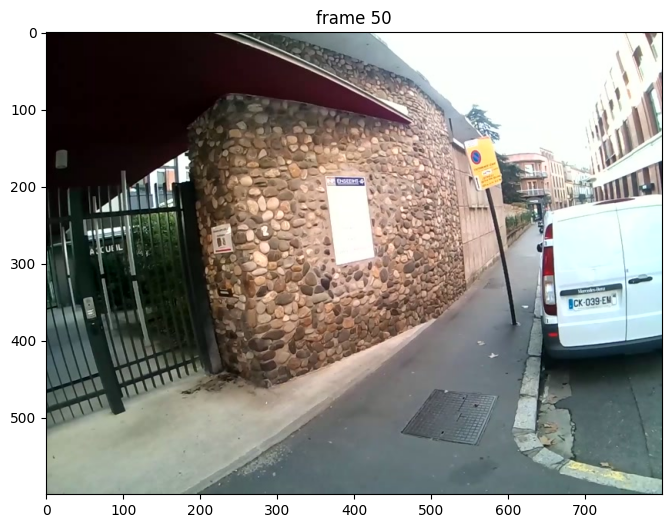

In [8]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "./videos/velo_1"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = NB_FRAMES //2
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

#### Initialize the inference state

In [9]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 1001/1001 [00:19<00:00, 51.88it/s]


In [10]:
predictor.reset_state(inference_state)

In [11]:
obj_id = 1 

for ann_frame_idx, x, y in triplets:
    if ann_frame_idx > NB_FRAMES:
        break

    print(f"Adding gaze point at frame {ann_frame_idx}, x={x}, y={y}")

    points = np.array([[x, y]], dtype=np.float32)
    labels = np.array([1], np.int32)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=obj_id,
        points=points,
        labels=labels,
    )


Adding gaze point at frame 28, x=301.0, y=187.0


C:\Users\romai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\romai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Adding gaze point at frame 34, x=544.0, y=263.0
Adding gaze point at frame 38, x=533.0, y=362.0
Adding gaze point at frame 43, x=462.0, y=388.0
Adding gaze point at frame 50, x=621.0, y=292.0
Adding gaze point at frame 54, x=595.0, y=277.0
Adding gaze point at frame 59, x=641.0, y=280.0
Adding gaze point at frame 63, x=641.0, y=256.0
Adding gaze point at frame 69, x=623.0, y=247.0
Adding gaze point at frame 85, x=308.0, y=274.0
Adding gaze point at frame 89, x=294.0, y=120.0
Adding gaze point at frame 94, x=319.0, y=147.0


In [ ]:
video_segments = {}

# predictor.model.eval()

with torch.no_grad():
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):

        # Seuil sur GPU (rapide)
        masks = out_mask_logits > 0.0  # bool tensor [N, H, W]

        # ⚠️ UNE SEULE sync GPU → CPU
        masks_cpu = masks.cpu().numpy()

        frame_dict = {}
        for i, out_obj_id in enumerate(out_obj_ids):
            frame_dict[out_obj_id] = masks_cpu[i]

        video_segments[out_frame_idx] = frame_dict

propagate in video:   6%|▌         | 55/973 [01:46<17:51,  1.17s/it] 

In [ ]:
import cv2
import numpy as np
from PIL import Image
import os

# Fonction pour superposer le masque sur l'image
def overlay_mask(image, mask, color=(0, 0, 255), alpha=0.5):
    """
    image: np.array HxWx3
    mask: bool HxW
    """
    # S'assurer que le masque a la bonne forme
    if mask.ndim == 3:
        mask = mask[0]  # parfois c'est (1, H, W)
    if mask.shape != image.shape[:2]:
        # redimensionner le masque si nécessaire
        mask = cv2.resize(mask.astype(np.uint8), (image.shape[1], image.shape[0]))
        mask = mask.astype(bool)
    
    overlay = image.copy()
    overlay[mask] = (np.array(color) * alpha + overlay[mask] * (1 - alpha)).astype(np.uint8)
    return overlay

# Récupérer les dimensions exactes de la première image
img0 = np.array(Image.open(os.path.join(video_dir, frame_names[0])).convert("RGB"))
height, width = img0.shape[:2]

# Paramètres vidéo
video_out_path = "video_with_masks.mp4"
fps = 30
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(video_out_path, fourcc, fps, (width, height))

# Boucle sur toutes les frames
for idx, frame_name in enumerate(frame_names):
    img = np.array(Image.open(os.path.join(video_dir, frame_names[idx])).convert("RGB"))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    
    if idx in video_segments:
        for out_obj_id, out_mask in video_segments[idx].items():
            img = overlay_mask(img, out_mask)
    
    video_writer.write(img)

video_writer.release()
print(f"Vidéo enregistrée dans {video_out_path}")
